In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import os
import tempfile

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import ocha_stratus as stratus
from scipy import stats

from src.utils import rp_calc


load_dotenv()

True

## Load data

In [22]:
# Geolayers
gdf_codab = stratus.codab.load_codab_from_blob("NGA", admin_level=0)
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)

In [23]:
# df_sev = stratus.load_csv_from_blob("ds-aa-nga-flooding/raw/AA-nigeria_data/OCHA/pin_target_and_severity_2026.csv")
# df_prioritized = df_sev[df_sev.Prioritized == "Y"]
# lgas_prioritized = list(df_prioritized.Pcodes)
# gdf_lga_sel = gdf_lga[gdf_lga["ADM2_PCODE"].isin(lgas_prioritized)]
# stratus.upload_parquet_to_blob(gdf_lga_sel, "ds-aa-nga-flooding/processed/selected_lgas_borno.parquet")

In [24]:
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas_borno.parquet"
)

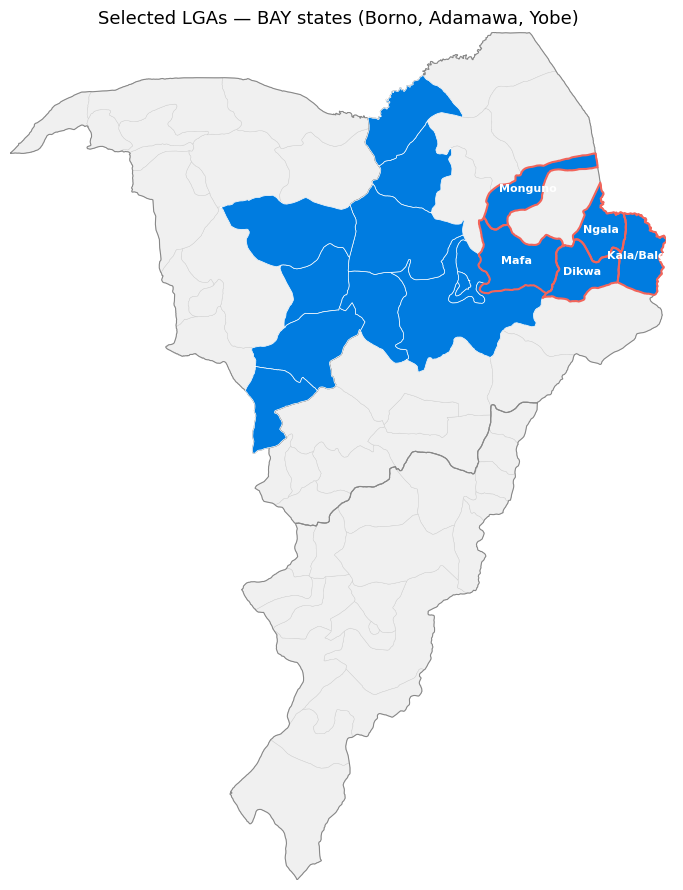

In [25]:
bay_states = ["Borno", "Adamawa", "Yobe"]
gdf_lga_bay = gdf_lga[gdf_lga["ADM1_EN"].isin(bay_states)]
gdf_adm1_bay = gdf_lga_bay.dissolve(by="ADM1_EN").reset_index()

xmin, ymin, xmax, ymax = gdf_lga_bay.total_bounds

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_bay.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.plot(ax=ax, facecolor="#007CE0", edgecolor="white", linewidth=0.5, zorder=3)

label_lgas = ["Ngala", "Monguno", "Kala/Balge", "Mafa", "Dikwa"]
gdf_labels = gdf_lga_sel[gdf_lga_sel["ADM2_EN"].isin(label_lgas)]
gdf_labels.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=1.5, zorder=4)
for _, row in gdf_labels.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y, row["ADM2_EN"],
        ha="center", va="center", fontsize=8, fontweight="bold",
        color="white", zorder=5,
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Selected LGAs — BAY states (Borno, Adamawa, Yobe)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/selected_lgas_borno.png", dpi=300, bbox_inches="tight")

In [26]:
# # Floodscan
# engine = stratus.get_engine("prod")
# pcodes = list(gdf_lga_sel['ADM2_PCODE'])

# with engine.connect() as conn:
#     query = """
#         SELECT * 
#         FROM floodscan 
#         WHERE pcode IN %(pcodes)s
#         AND band = 'SFED'
#     """
#     df_floodscan = pd.read_sql(query, engine, params={'pcodes': tuple(pcodes)}, parse_dates=["valid_date"])
# stratus.upload_parquet_to_blob(df_floodscan, "ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet")

In [27]:
df_floodscan = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet")

If running for the first time...

In [28]:
# # Groundsource
# gdf = stratus.load_geoparquet_from_blob("vector/raw/groundsource_2026.parquet", container_name="global")

# # # Only keep those that intersect with the selected LGAs
# gdf_flood_sel = gdf.sjoin(gdf_lga_sel, predicate="intersects")
# gdf_flood_sel = gdf_flood_sel.drop_duplicates(subset='uuid')
# gdf_flood_sel = gdf_flood_sel[gdf_flood_sel["area_km2"] >= 1]

# stratus.upload_parquet_to_blob(gdf_flood_sel, "ds-aa-nga-flooding/processed/groundsource_flood_sel_borno.parquet")

In [29]:
gdf_flood_sel = stratus.load_geoparquet_from_blob("ds-aa-nga-flooding/processed/groundsource_flood_sel_borno.parquet")
print(f"Loaded {len(gdf_flood_sel)} flood polygons from blob")

Loaded 413 flood polygons from blob


Also get the NiHSA food reports

In [30]:
df_nihsa = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/nihsa/floodhistory_2013_2023_sel_lgas_borno.parquet")

## Calculate Floodscan return periods

In [31]:
# Calculate return periods
df_floodscan["year"] = df_floodscan["valid_date"].dt.year
df_floodscan = df_floodscan[df_floodscan.year != 2026]

df_floodscan_valid = df_floodscan.groupby(["pcode", "year"]).filter(
    lambda x: x["mean"].notna().any()
)

df_floodscan_max = df_floodscan_valid.loc[
    df_floodscan_valid.groupby(["pcode", "year"])["mean"].idxmax()
][["pcode", "year", "valid_date", "mean"]]

df_floodscan_rp = rp_calc.calculate_groups_rp(
    df_floodscan_max, by=["pcode"], col_name="mean", ascending=False
)

# Get average return period per year across all LGAs
df_floodscan_rp_yearly = (
    df_floodscan_rp.groupby("year")["mean_rp"]
    .mean()
    .reset_index()
)

## Calculate Groundsource events per year

In [32]:
gdf_flood_sel["start_date"] = pd.to_datetime(gdf_flood_sel["start_date"])
gdf_flood_sel['start_year'] = gdf_flood_sel['start_date'].dt.year

df_gs_events = (
    gdf_flood_sel.groupby("start_year")["uuid"]
    .nunique()
    .reset_index()
    .rename(columns={"start_year": "year", "uuid": "n_flood_events"})
)

## Calculate and plot correlation

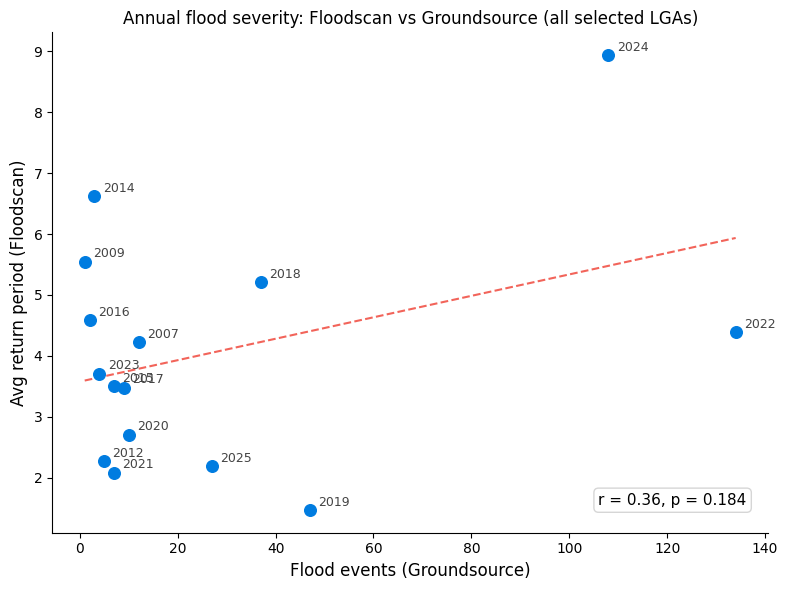

In [33]:
df_scatter = df_floodscan_rp_yearly.merge(df_gs_events, on="year").dropna()
r, p = stats.pearsonr(df_scatter["n_flood_events"], df_scatter["mean_rp"])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_scatter["n_flood_events"], df_scatter["mean_rp"], color="#007CE0", s=70, zorder=3)

for _, row in df_scatter.iterrows():
    ax.annotate(
        str(int(row["year"])),
        (row["n_flood_events"], row["mean_rp"]),
        textcoords="offset points", xytext=(6, 3),
        fontsize=9, color="#444444",
    )

m, b, *_ = stats.linregress(df_scatter["n_flood_events"], df_scatter["mean_rp"])
x_line = np.linspace(df_scatter["n_flood_events"].min(), df_scatter["n_flood_events"].max(), 100)
ax.plot(x_line, m * x_line + b, color="#F2645A", linewidth=1.5, linestyle="--", zorder=2)

p_str = f"p = {p:.3f}" if p >= 0.001 else "p < 0.001"
ax.text(
    0.97, 0.05, f"r = {r:.2f}, {p_str}",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc", alpha=0.8),
)

ax.set_xlabel("Flood events (Groundsource)", fontsize=12)
ax.set_ylabel("Avg return period (Floodscan)", fontsize=12)
ax.set_title("Annual flood severity: Floodscan vs Groundsource (all selected LGAs)", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("figures/floodscan_groundsource_correlation.png", dpi=300)

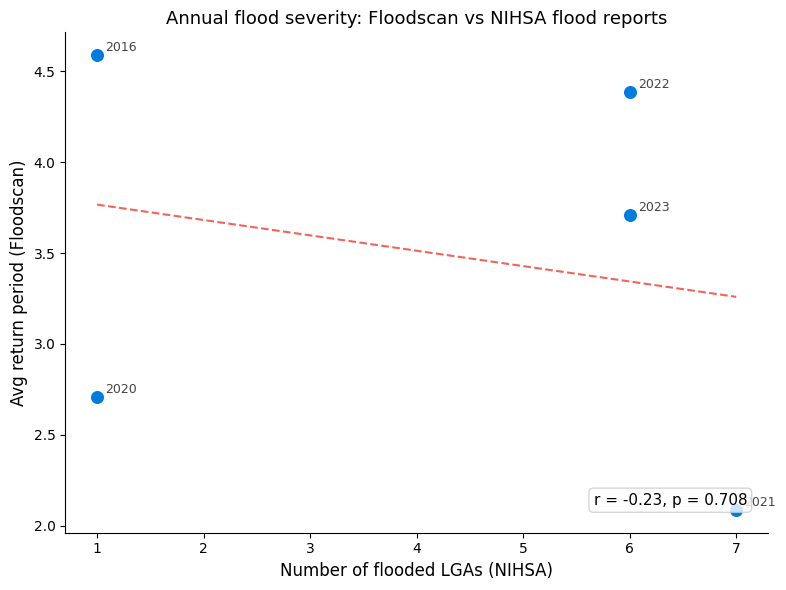

In [34]:
# --- Scatter: avg RP (Floodscan) vs number of flooded LGAs (NIHSA) ---
df_nihsa_flooded = (
    df_nihsa[df_nihsa["Flooded"]]
    .groupby("Year")["ADM2_PCODE"]
    .nunique()
    .reset_index()
    .rename(columns={"Year": "year", "ADM2_PCODE": "n_flooded_lgas"})
)

df_scatter_nihsa = df_floodscan_rp_yearly.merge(df_nihsa_flooded, on="year").dropna()

r2, p2 = stats.pearsonr(df_scatter_nihsa["n_flooded_lgas"], df_scatter_nihsa["mean_rp"])

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_scatter_nihsa["n_flooded_lgas"], df_scatter_nihsa["mean_rp"], color="#007CE0", s=70, zorder=3)

for _, row in df_scatter_nihsa.iterrows():
    ax.annotate(
        str(int(row["year"])),
        (row["n_flooded_lgas"], row["mean_rp"]),
        textcoords="offset points",
        xytext=(6, 3),
        fontsize=9,
        color="#444444",
    )

m2, b2, *_ = stats.linregress(df_scatter_nihsa["n_flooded_lgas"], df_scatter_nihsa["mean_rp"])
x_line2 = np.linspace(df_scatter_nihsa["n_flooded_lgas"].min(), df_scatter_nihsa["n_flooded_lgas"].max(), 100)
ax.plot(x_line2, m2 * x_line2 + b2, color="#F2645A", linewidth=1.5, linestyle="--", zorder=2)

p_str2 = f"p = {p2:.3f}" if p2 >= 0.001 else "p < 0.001"
ax.text(
    0.97, 0.05,
    f"r = {r2:.2f}, {p_str2}",
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=11,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc", alpha=0.8),
)

ax.set_xlabel("Number of flooded LGAs (NIHSA)", fontsize=12)
ax.set_ylabel("Avg return period (Floodscan)", fontsize=12)
ax.set_title("Annual flood severity: Floodscan vs NIHSA flood reports", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

## NiHSA flood years per LGA

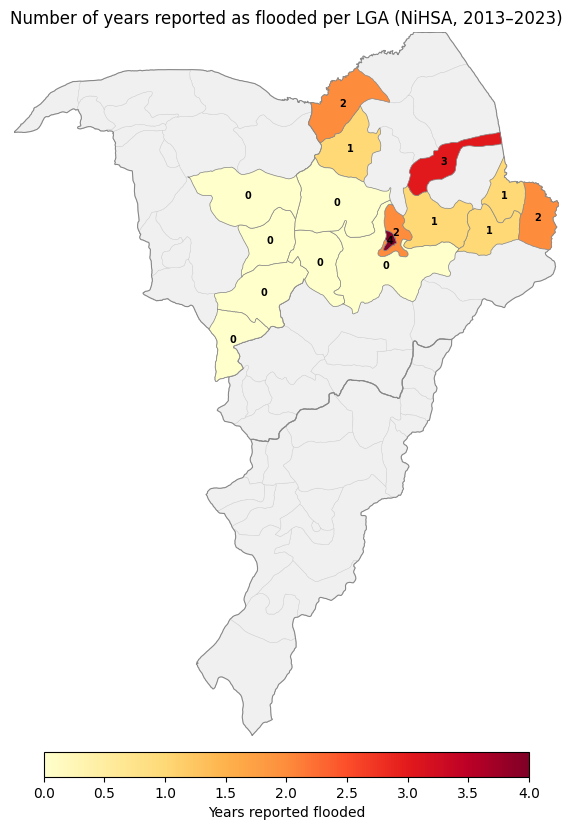

In [35]:
df_nihsa_years = (
    df_nihsa[df_nihsa["Flooded"]]
    .groupby("ADM2_PCODE")["Year"]
    .nunique()
    .reset_index()
    .rename(columns={"Year": "n_flooded_years"})
)

gdf_nihsa_choro = gdf_lga_sel.merge(df_nihsa_years, on="ADM2_PCODE", how="left")
gdf_nihsa_choro["n_flooded_years"] = gdf_nihsa_choro["n_flooded_years"].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_bay.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)

gdf_nihsa_choro.plot(
    ax=ax,
    column="n_flooded_years",
    cmap="YlOrRd",
    edgecolor="#888888",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Years reported flooded", "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
    zorder=3,
)

for _, row in gdf_nihsa_choro.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x, centroid.y, str(row["n_flooded_years"]),
        ha="center", va="center", fontsize=7, fontweight="bold", color="black",
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Number of years reported as flooded per LGA (NiHSA, 2013–2023)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/nihsa_flooded_years_choropleth.png", dpi=300, bbox_inches="tight")

## Seasonal flood profile per LGA (Floodscan SFED)

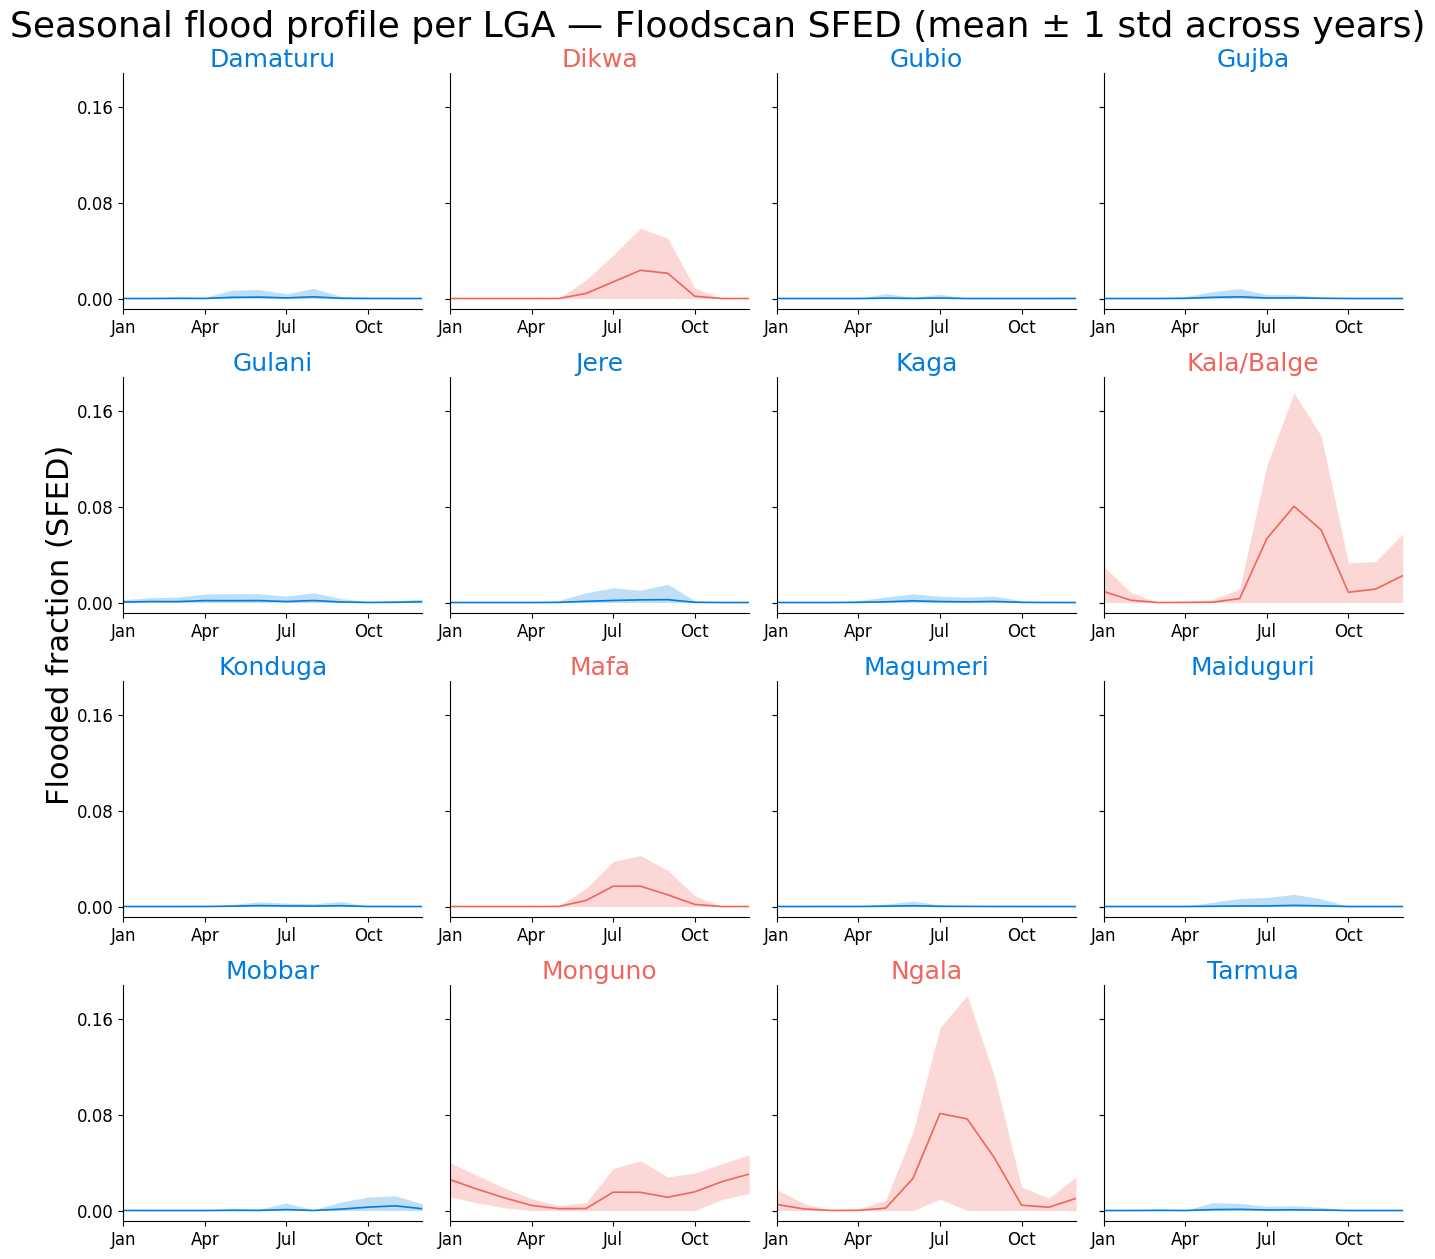

In [43]:
df_fs = df_floodscan.copy()
df_fs["month"] = pd.to_datetime(df_fs["valid_date"]).dt.month

df_monthly = (
    df_fs.groupby(["pcode", "month"])["mean"]
    .agg(["mean", "std"])
    .reset_index()
)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
tick_months = [1, 4, 7, 10]
tick_labels = [month_labels[m - 1] for m in tick_months]

label_lgas = ["Ngala", "Monguno", "Kala/Balge", "Mafa", "Dikwa"]

lgas = gdf_lga_sel[["ADM2_PCODE", "ADM2_EN"]].drop_duplicates().sort_values("ADM2_EN")
pcodes = lgas["ADM2_PCODE"].tolist()
n = len(pcodes)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.2), sharey=True)
axes_flat = axes.flat

for ax, pcode in zip(axes_flat, pcodes):
    lga_name = lgas.loc[lgas["ADM2_PCODE"] == pcode, "ADM2_EN"].iloc[0]
    sub = df_monthly[df_monthly["pcode"] == pcode].sort_values("month")

    color = "#F2645A" if lga_name in label_lgas else "#007CE0"

    ax.fill_between(
        sub["month"],
        (sub["mean"] - sub["std"]).clip(lower=0),
        sub["mean"] + sub["std"],
        alpha=0.25, color=color, linewidth=0,
    )
    ax.plot(sub["month"], sub["mean"], color=color, linewidth=1.2)
    ax.set_title(lga_name, fontsize=18, pad=4, color=color)
    ax.set_xticks(tick_months)
    ax.set_xticklabels(tick_labels, fontsize=12)
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    ax.tick_params(axis="y", labelsize=12)
    ax.set_xlim(1, 12)
    ax.spines[["top", "right"]].set_visible(False)

for ax in list(axes_flat)[len(pcodes):]:
    ax.set_visible(False)

fig.supylabel("Flooded fraction (SFED)", fontsize=22)
fig.suptitle("Seasonal flood profile per LGA — Floodscan SFED (mean ± 1 std across years)", fontsize=26)
plt.tight_layout()
plt.savefig("figures/sfed_monthly_facet.png", dpi=300, bbox_inches="tight")

## Google inundation history vs selected LGAs

Inundation polygons within BAY states: 3


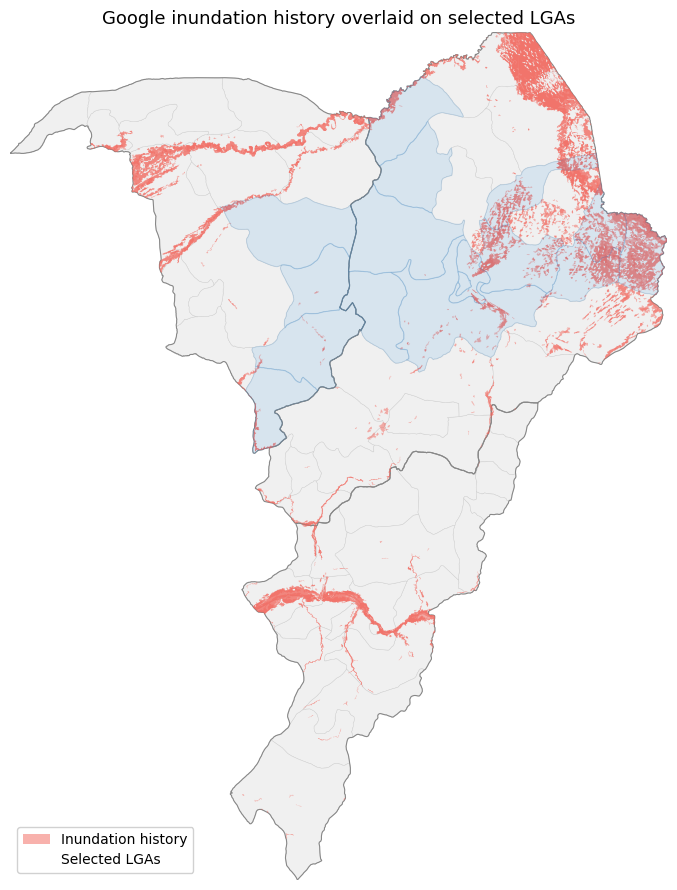

In [37]:
gdf_inundation = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/google_inundation_history/combined_nga.parquet"
)

# Clip inundation to BAY states bounds
gdf_inundation_bay = gpd.clip(gdf_inundation, gdf_adm1_bay.union_all())
print(f"Inundation polygons within BAY states: {len(gdf_inundation_bay)}")

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_bay.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_inundation_bay.plot(ax=ax, facecolor="#F2645A", edgecolor="none", alpha=0.5, zorder=3)
gdf_lga_sel.boundary.plot(ax=ax, edgecolor="#007CE0", facecolor="#007CE0", linewidth=0.8, zorder=4, alpha=0.1)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("Google inundation history overlaid on selected LGAs", fontsize=13)
ax.set_axis_off()

from matplotlib.patches import Patch
ax.legend(
    handles=[
        Patch(facecolor="#F2645A", alpha=0.5, label="Inundation history"),
        Patch(facecolor="none", edgecolor="white", linewidth=0.8, label="Selected LGAs"),
    ],
    loc="lower left", fontsize=10, framealpha=0.9,
)

plt.tight_layout()
plt.savefig("figures/inundation_selected_lgas.png", dpi=300, bbox_inches="tight")

## NiHSA flood risk communities

Communities within BAY states: 7,210


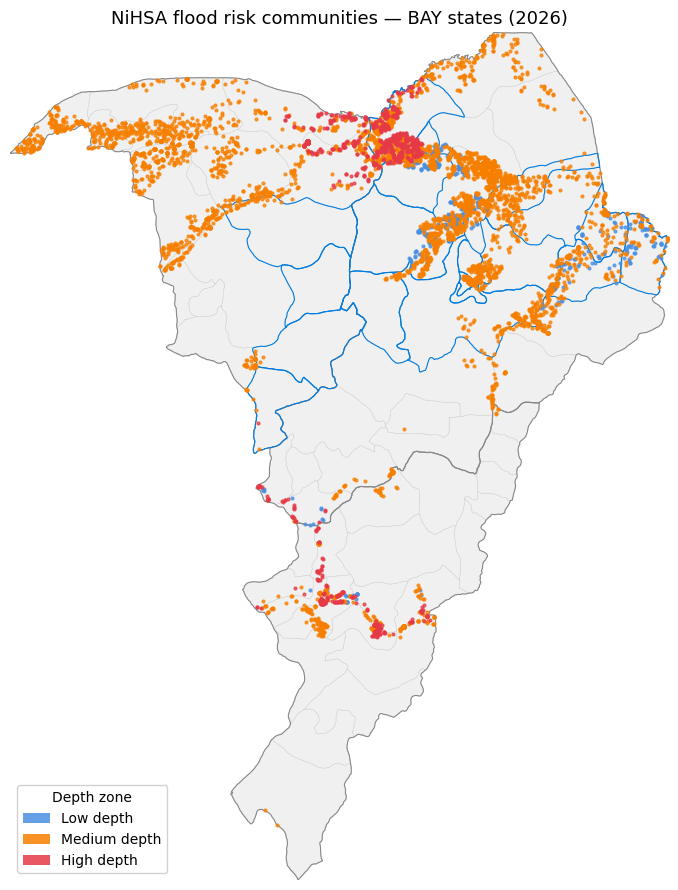

In [38]:
from matplotlib.patches import Patch

df_risk = stratus.load_csv_from_blob("ds-aa-nga-flooding/raw/AA-nigeria_data/NiHSA/AFO_communities_atrisk_2026.csv")
df_risk["depth_zone"] = df_risk["depth_zone"].str.strip().str.capitalize()

gdf_risk = gpd.GeoDataFrame(
    df_risk,
    geometry=gpd.points_from_xy(df_risk["lon"], df_risk["lat"]),
    crs="EPSG:4326",
)

# Keep communities within BAY states bounds
gdf_risk_bay = gdf_risk[gdf_risk.within(gdf_adm1_bay.union_all())]
print(f"Communities within BAY states: {len(gdf_risk_bay):,}")

ZONE_ORDER  = ["Low", "Medium", "High"]
ZONE_COLORS = {"Low": "#4A90E2", "Medium": "#F77F00", "High": "#E63946"}

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_bay.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.boundary.plot(ax=ax, edgecolor="#007CE0", linewidth=0.8, zorder=3)

for zone in ZONE_ORDER:
    sub = gdf_risk_bay[gdf_risk_bay["depth_zone"] == zone]
    sub.plot(ax=ax, color=ZONE_COLORS[zone], markersize=4, alpha=0.75, zorder=4)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title("NiHSA flood risk communities — BAY states (2026)", fontsize=13)
ax.set_axis_off()

ax.legend(
    handles=[Patch(facecolor=ZONE_COLORS[z], alpha=0.85, label=f"{z} depth") for z in ZONE_ORDER],
    loc="lower left", fontsize=10, title="Depth zone", title_fontsize=10, framealpha=0.9,
)

plt.tight_layout()
plt.savefig("figures/nihsa_risk_communities_map.png", dpi=300, bbox_inches="tight")

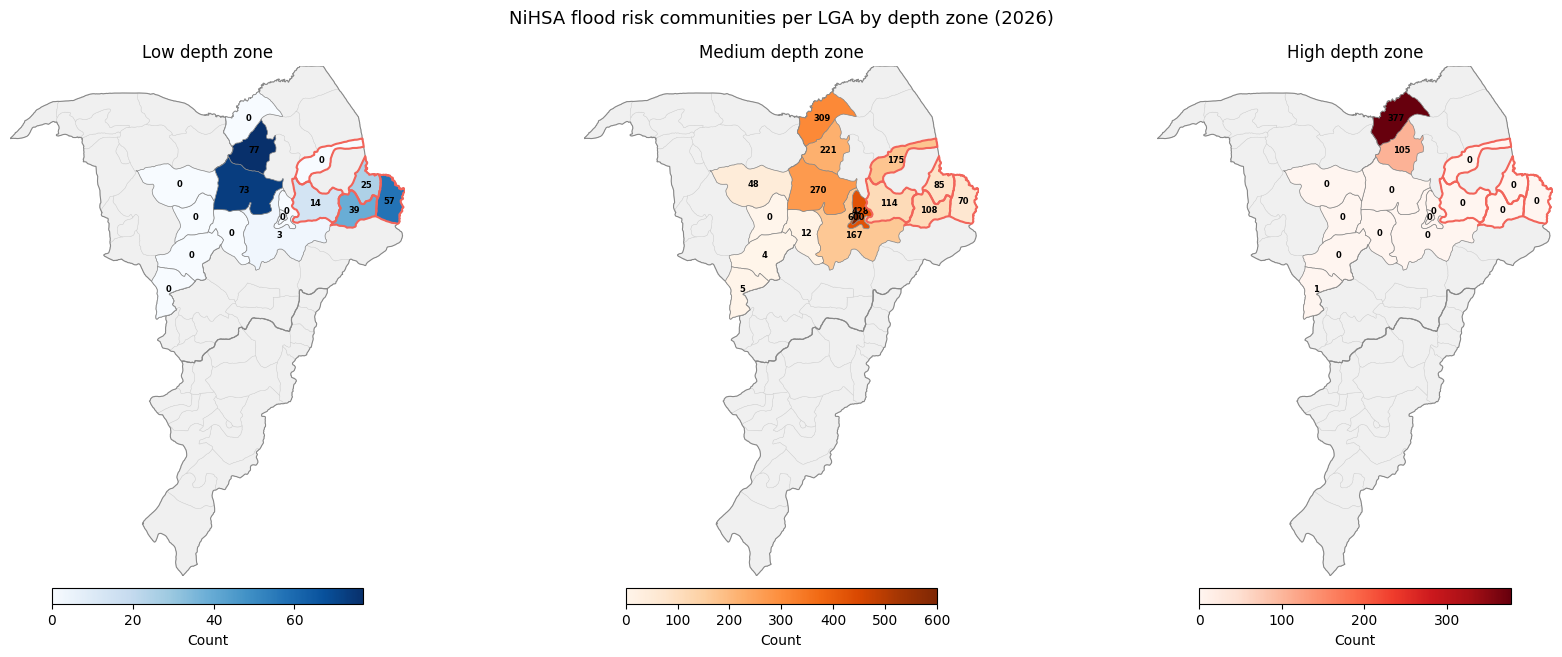

In [45]:
# Count risk communities per LGA per depth zone
gdf_risk_lga = gpd.sjoin(gdf_risk_bay, gdf_lga_sel[["ADM2_PCODE", "geometry"]], how="inner", predicate="within")

df_counts = (
    gdf_risk_lga.groupby(["ADM2_PCODE", "depth_zone"])
    .size()
    .reset_index(name="count")
)

label_lgas = ["Ngala", "Monguno", "Kala/Balge", "Mafa", "Dikwa"]
gdf_focal = gdf_lga_sel[gdf_lga_sel["ADM2_EN"].isin(label_lgas)]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, zone in zip(axes, ZONE_ORDER):
    df_zone = df_counts[df_counts["depth_zone"] == zone]
    gdf_zone = gdf_lga_sel.merge(df_zone[["ADM2_PCODE", "count"]], on="ADM2_PCODE", how="left")
    gdf_zone["count"] = gdf_zone["count"].fillna(0).astype(int)

    gdf_lga_bay.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
    gdf_adm1_bay.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
    gdf_zone.plot(
        ax=ax, column="count",
        cmap="Blues" if zone == "Low" else ("Oranges" if zone == "Medium" else "Reds"),
        edgecolor="#888888", linewidth=0.5,
        legend=True,
        legend_kwds={"label": "Count", "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
        zorder=3,
    )
    gdf_focal.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=1.5, zorder=4)

    for _, row in gdf_zone.iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, str(row["count"]),
                ha="center", va="center", fontsize=6, fontweight="bold", color="black")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(f"{zone} depth zone", fontsize=12)
    ax.set_axis_off()

fig.suptitle("NiHSA flood risk communities per LGA by depth zone (2026)", fontsize=13)
plt.tight_layout()
plt.savefig("figures/nihsa_risk_communities_choropleth.png", dpi=300, bbox_inches="tight")